In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv(r'C:\Users\sumit\OneDrive\Desktop\TV advertise\advertising_cleaned.csv')
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())


ModuleNotFoundError: No module named 'sklearn'

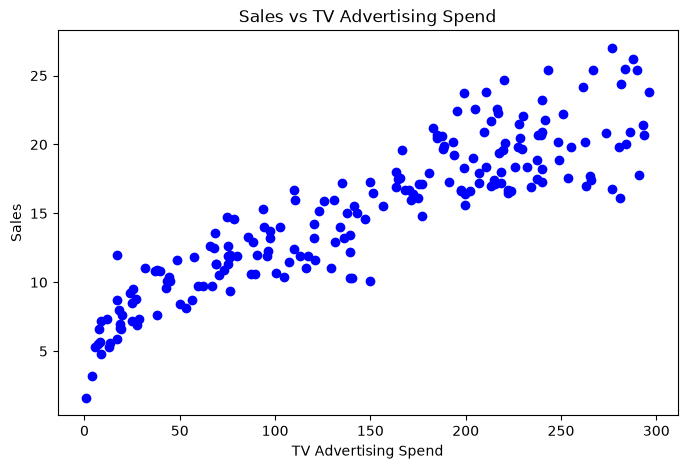

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['tv'], df['sales'], color='blue')
plt.title('Sales vs TV Advertising Spend')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.show()

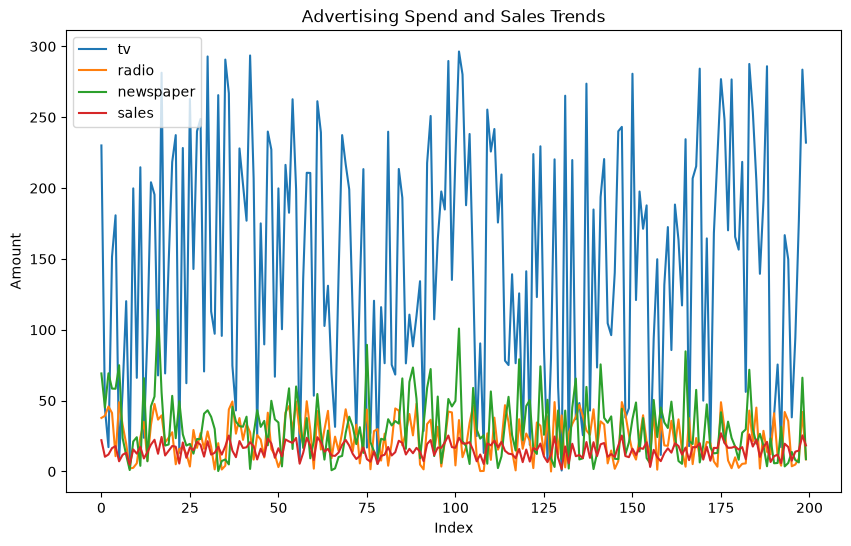

In [ ]:
df[['tv', 'radio', 'newspaper', 'sales']].plot(kind='line', figsize=(10,6))
plt.title('Advertising Spend and Sales Trends')
plt.xlabel('Index')
plt.ylabel('Amount')
plt.show()

In [ ]:
# Correlation matrix
corr = df.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Between Advertising Channels and Sales')
plt.show()

print(corr['sales'].sort_values(ascending=False))


NameError: name 'df' is not defined

Intercept: 6.9748214882298925
Coefficient: 0.05546477046955886


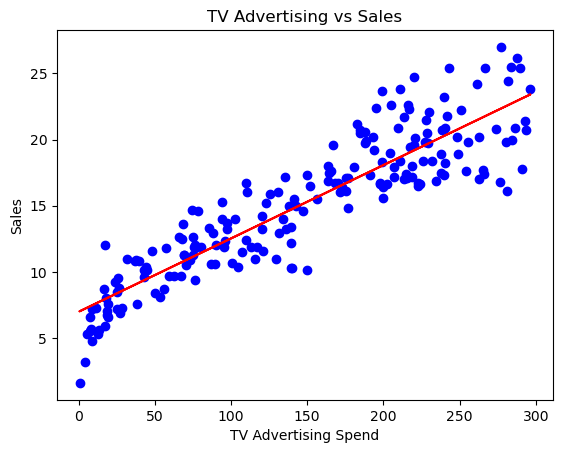

In [ ]:
from sklearn.linear_model import LinearRegression

X = df[['tv']]   # change to ['radio'] or ['newspaper'] for others
y = df['sales']

model = LinearRegression()
model.fit(X, y)

print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_[0]}")

plt.scatter(X, y, color='blue')
plt.plot(X, model.predict(X), color='red')
plt.title('TV Advertising vs Sales')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.show()

In [ ]:
X = df[['tv', 'radio', 'newspaper']]
y = df['sales']

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(f"{col}: {coef}")

# Train/test split for evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n🔹 Model Performance:")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"R-squared (R²): {r2:.3f}")


Intercept: 4.625124078808653
Coefficients:
tv: 0.05444578033757093
radio: 0.10700122823870299
newspaper: 0.0003356579223305978


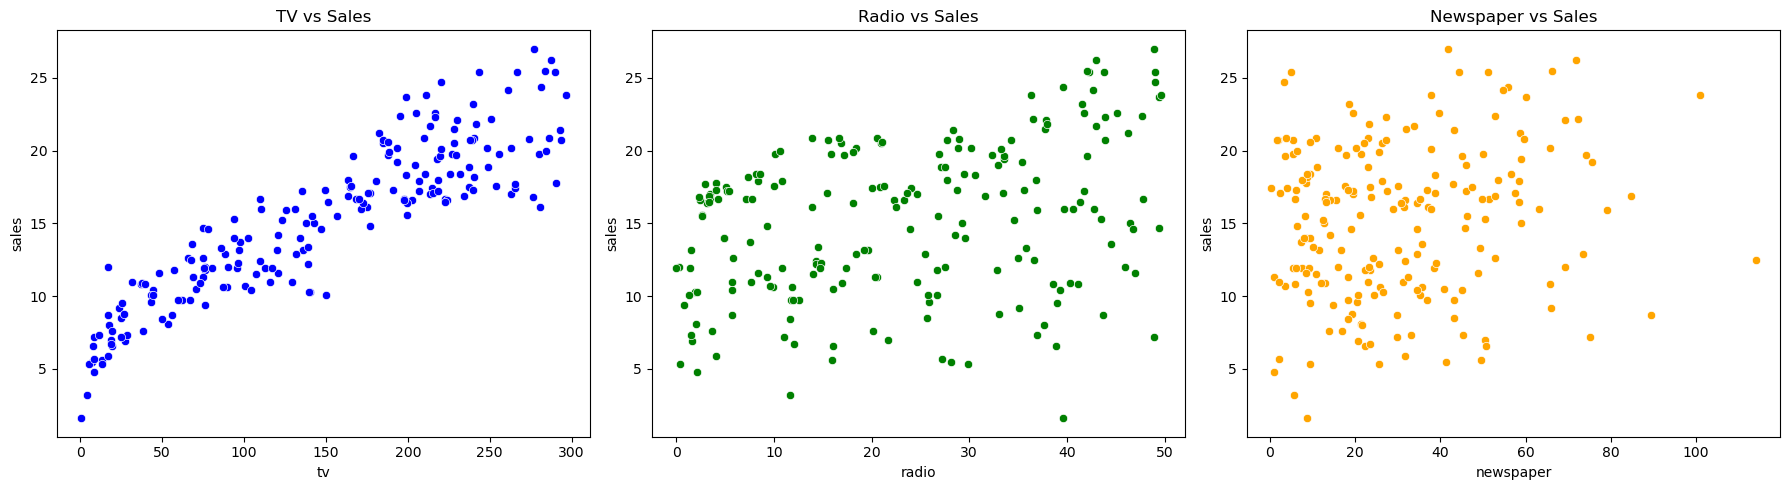

In [ ]:
# Relationship between TV, Radio, Newspaper and Sales
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(ax=axes[0], data=df, x='tv', y='sales', color='blue')
axes[0].set_title('TV vs Sales')

sns.scatterplot(ax=axes[1], data=df, x='radio', y='sales', color='green')
axes[1].set_title('Radio vs Sales')

sns.scatterplot(ax=axes[2], data=df, x='newspaper', y='sales', color='orange')
axes[2].set_title('Newspaper vs Sales')

plt.tight_layout()
plt.show()

In [ ]:
# This cell is now redundant after the train/test evaluation in the previous cell.
# Kept intentionally empty to avoid undefined variable errors.



🔹 Model Performance:
Mean Squared Error (MSE): 2.908
R-squared (R²): 0.906


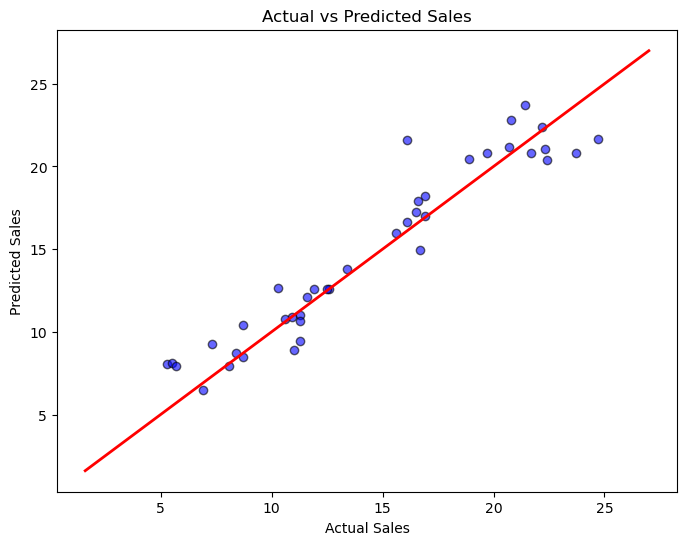

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.title('Actual vs Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()



🔹 Feature Coefficients:


,Feature,Coefficient
1,radio,0.100945
0,tv,0.054509
2,newspaper,0.004337


C:\Users\yadan\AppData\Local\Temp\ipykernel_4576\4229524403.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coefficients, x='Feature', y='Coefficient', palette='viridis')


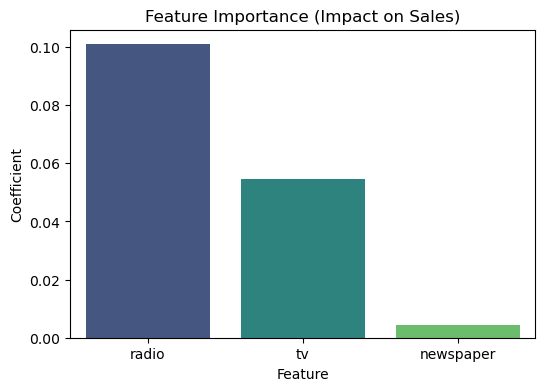

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n🔹 Feature Coefficients:")
print(coefficients)

# Visualize feature importance
plt.figure(figsize=(6,4))
sns.barplot(data=coefficients, x='Feature', y='Coefficient', palette='viridis')
plt.title('Feature Importance (Impact on Sales)')
plt.show()
